In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

In [72]:
df=pd.read_csv("ai4i2020.csv", index_col="UDI")

df.head()

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,,,,,,,,,,,,,
1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


I decided to drop Product ID, because it is not a valuable information to our model (this is only an ID).

In [73]:
df.drop(columns="Product ID", inplace=True)
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
UDI,,,,,,,,,,,,
1,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
2,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
3,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
4,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
5,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Checking if there are missing values and how much is unique values.

In [74]:
print("Missing values count:\n", df.isnull().sum())
print("\nUnique values count: \n", df.nunique())

Missing values count:
 Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Unique values count: 
 Type                         3
Air temperature [K]         93
Process temperature [K]     82
Rotational speed [rpm]     941
Torque [Nm]                577
Tool wear [min]            246
Machine failure              2
TWF                          2
HDF                          2
PWF                          2
OSF                          2
RNF                          2
dtype: int64


There are no NA values. There is a lot of unique values, however there are essential for our model. There are no incorrect values when it comes to machine failure or type of machine. Now, it is crucial we inspect if there are outliers. But firstly I wanted to change Kelvins to Celsius temperature to make the interpretation easier.

In [75]:
df["Air temperature [C]"]=df["Air temperature [K]"]-273.15
df.drop(columns="Air temperature [K]", inplace=True)

df["Process temperature [C]"]=df["Process temperature [K]"]-273.15
df.drop(columns="Process temperature [K]", inplace=True)

df.head()

,Type,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Air temperature [C],Process temperature [C]
UDI,,,,,,,,,,,,
1,M,1551,42.8,0,0,0,0,0,0,0,24.95,35.45
2,L,1408,46.3,3,0,0,0,0,0,0,25.05,35.55
3,L,1498,49.4,5,0,0,0,0,0,0,24.95,35.35
4,L,1433,39.5,7,0,0,0,0,0,0,25.05,35.45
5,L,1408,40.0,9,0,0,0,0,0,0,25.05,35.55


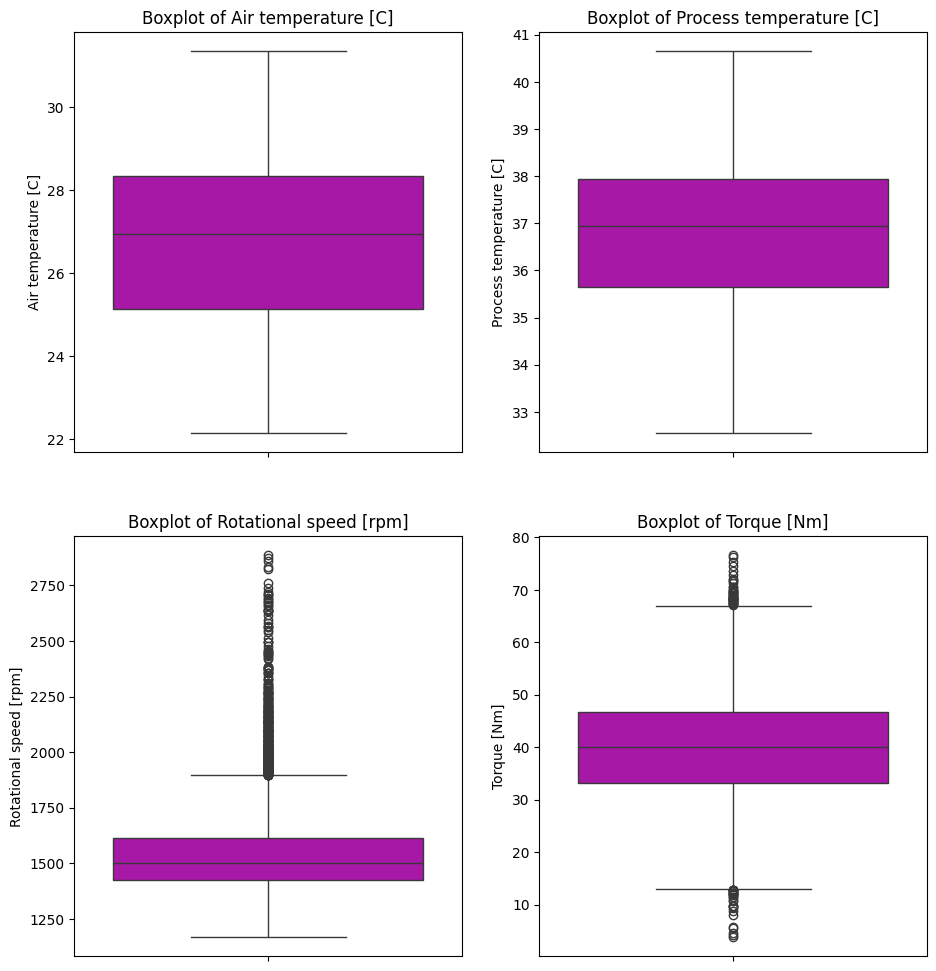

In [76]:
plt.figure(figsize=(11,12))
i=1
cols=["Air temperature [C]", "Process temperature [C]", "Rotational speed [rpm]", "Torque [Nm]"]
for i, cols in enumerate(cols, i):
    plt.subplot(2,2,i)
    sns.boxplot(data=df[cols], color="m")
    plt.title(f"Boxplot of {cols}")


There are a lot of outliers in both Rotational speed and Torque values. However, there could be realistic (depending on type of machine) so I decided to keep them.

Let's see there is an imbalanced data.

Text(0.5, 1.0, 'Class Distribution of Machine failure')

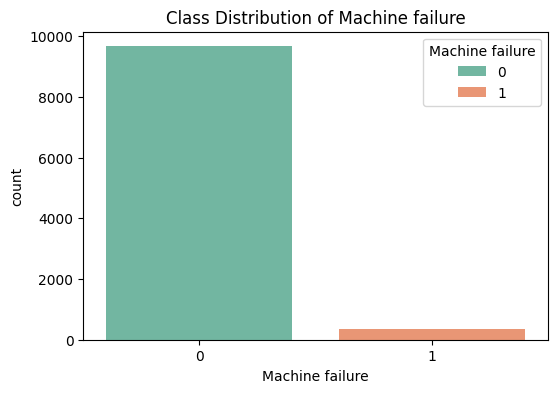

In [77]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Machine failure", palette="Set2", hue='Machine failure')
plt.title("Class Distribution of Machine failure")


Now is the time to carry out One Hot Encoding for the Type column.

In [78]:
ohe=OneHotEncoder(sparse_output=False)
data=ohe.fit_transform(df[["Type"]])
col_names=ohe.get_feature_names_out(["Type"])

data_fr=pd.DataFrame(data, columns=col_names, index=df.index)
df=pd.concat([df.drop(columns="Type"), data_fr], axis=1 )
df.head()

,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Air temperature [C],Process temperature [C],Type_H,Type_L,Type_M
UDI,,,,,,,,,,,,,,
1,1551,42.8,0,0,0,0,0,0,0,24.95,35.45,0.0,0.0,1.0
2,1408,46.3,3,0,0,0,0,0,0,25.05,35.55,0.0,1.0,0.0
3,1498,49.4,5,0,0,0,0,0,0,24.95,35.35,0.0,1.0,0.0
4,1433,39.5,7,0,0,0,0,0,0,25.05,35.45,0.0,1.0,0.0
5,1408,40.0,9,0,0,0,0,0,0,25.05,35.55,0.0,1.0,0.0


<Axes: >

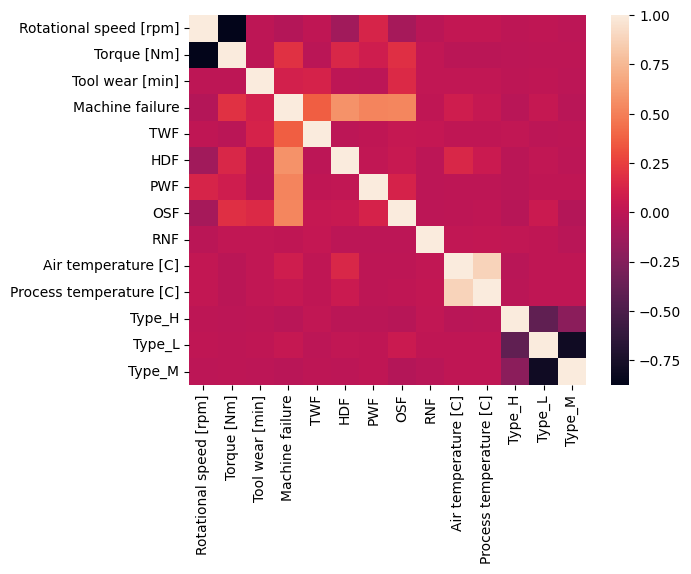

In [79]:
df_corr=df.corr()

sns.heatmap(df_corr)